<a href="https://colab.research.google.com/github/CalculatedContent/xgboost2ww/blob/main/notebooks/AdultIncome_LongRun_Alpha_Tracking2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Adult Income Long-Run Alpha Tracking (Single Configuration)


In [2]:
from pathlib import Path
import os
import platform

RANDOM_STATE = 42

CPU_THREADS = max(1, (os.cpu_count() or 1) - 1)
IS_APPLE_SILICON = platform.system() == 'Darwin' and platform.machine() == 'arm64'

params = {
    'max_depth': 4,
    'eta': 0.05,
    'subsample': 0.9,
    'colsample_bytree': 0.8,
    'min_child_weight': 5,
    'reg_lambda': 5.0,
    'reg_alpha': 0.5,
    'gamma': 1.0,
    'objective': 'binary:logistic',
    'eval_metric': 'logloss',
    # Apple Silicon (M1/M2/M3) benefits from CPU histogram + multithreading.
    # XGBoost GPU backends are not used on macOS ARM, so tune CPU threads instead.
    'tree_method': 'hist',
    'nthread': CPU_THREADS,
    'seed': RANDOM_STATE,
}

TOTAL_ROUNDS = 1200
CHUNK_SIZE = 25
N_STEPS = TOTAL_ROUNDS // CHUNK_SIZE
CHECKPOINT_EVERY_STEPS = 1
RESUME_FROM_CHECKPOINT = False

in_colab = False
try:
    from google.colab import drive
    in_colab = True
except ImportError:
    drive = None

if in_colab:
    drive.mount('/content/drive', force_remount=False)
    project_root = Path('/content/drive/MyDrive/xgboost2ww_runs/adult_income_longrun_alpha_tracking2')
    print(f'Google Drive enabled: {project_root}')
else:
    project_root = Path('.')
    print('Google Drive unavailable; using local notebook storage.')

results_dir = project_root / 'results'
models_dir = project_root / 'models'
results_dir.mkdir(parents=True, exist_ok=True)
models_dir.mkdir(parents=True, exist_ok=True)

results_path_csv = results_dir / 'adult_income_longrun_alpha_tracking.csv'
results_path_feather = results_dir / 'adult_income_longrun_alpha_tracking.feather'
latest_model_path = models_dir / 'adult_income_longrun_latest.json'

print(f'TOTAL_ROUNDS={TOTAL_ROUNDS}, CHUNK_SIZE={CHUNK_SIZE}, N_STEPS={N_STEPS}')
print(f'CHECKPOINT_EVERY_STEPS={CHECKPOINT_EVERY_STEPS}')
print(f'RESUME_FROM_CHECKPOINT={RESUME_FROM_CHECKPOINT}')
print(f'CPU_THREADS={CPU_THREADS} | IS_APPLE_SILICON={IS_APPLE_SILICON}')
print(f"XGBoost config: tree_method={params['tree_method']}, nthread={params['nthread']}")
print(f'Results CSV path: {results_path_csv}')


Mounted at /content/drive
Google Drive enabled: /content/drive/MyDrive/xgboost2ww_runs/adult_income_longrun_alpha_tracking2
TOTAL_ROUNDS=1200, CHUNK_SIZE=25, N_STEPS=48
CHECKPOINT_EVERY_STEPS=1
RESUME_FROM_CHECKPOINT=False
CPU_THREADS=1 | IS_APPLE_SILICON=False
XGBoost config: tree_method=hist, nthread=1
Results CSV path: /content/drive/MyDrive/xgboost2ww_runs/adult_income_longrun_alpha_tracking2/results/adult_income_longrun_alpha_tracking.csv


## 1) Bootstrap environment

In [13]:
%pip install -q xgboost weightwatcher scikit-learn pandas matplotlib seaborn scipy feather-format
!git clone --depth 1 https://github.com/CalculatedContent/xgboost2ww.git /tmp/xgboost2ww-src || true
%pip install -q /tmp/xgboost2ww-src


fatal: destination path '/tmp/xgboost2ww-src' already exists and is not an empty directory.
Fatal Python error: init_import_site: Failed to import the site module
Python runtime state: initialized
Traceback (most recent call last):
  File "<frozen importlib._bootstrap>", line 1360, in _find_and_load
  File "<frozen importlib._bootstrap>", line 1331, in _find_and_load_unlocked
  File "<frozen importlib._bootstrap>", line 935, in _load_unlocked
  File "<frozen importlib._bootstrap>", line 1176, in exec_module
  File "<frozen site>", line 652, in <module>
  File "<frozen site>", line 639, in main
  File "<frozen site>", line 421, in addsitepackages
  File "<frozen site>", line 247, in addsitedir
KeyboardInterrupt


## 2) Imports

In [3]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score

import xgboost as xgb
import weightwatcher as ww
from xgboost2ww import convert

sns.set_theme(style='whitegrid')
RANDOM_STATE = 42

ModuleNotFoundError: No module named 'weightwatcher'

## 3) Load Adult Income dataset


In [15]:
from sklearn.datasets import fetch_openml
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer

adult = fetch_openml(data_id=1590, as_frame=True)
df = adult.frame.copy()

y = (df['class'].astype(str) == '>50K').astype(int)
X_raw = df.drop(columns=['class'])

categorical_cols = X_raw.select_dtypes(include=['object', 'category']).columns
numeric_cols = X_raw.select_dtypes(exclude=['object', 'category']).columns

preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_cols),
        ('num', 'passthrough', numeric_cols),
    ]
)

X = preprocessor.fit_transform(X_raw).astype(np.float32)

print(f'X shape: {X.shape}')
print(f'y mean (income >50K prevalence): {y.mean():.3f}')


X shape: (48842, 108)
y mean (income >50K prevalence): 0.239


## 4) Train/test split (80/20) and scaling


In [16]:
from scipy import sparse

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y,
)

if sparse.issparse(X_train):
    scaler = StandardScaler(with_mean=False)
else:
    scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train).astype(np.float32)
X_test_scaled = scaler.transform(X_test).astype(np.float32)
y_train_np = np.asarray(y_train).astype(np.int32).reshape(-1)
y_test_np = np.asarray(y_test).astype(np.int32).reshape(-1)

# xgboost2ww currently expects dense numpy arrays in convert().
# Keep sparse matrices for XGBoost training, but densify once for alpha tracking when safe.
MAX_DENSE_ELEMENTS = int(2e8)  # ~0.8GB float32
if sparse.issparse(X_train_scaled):
    dense_cost = int(X_train_scaled.shape[0]) * int(X_train_scaled.shape[1])
    if dense_cost > MAX_DENSE_ELEMENTS:
        raise MemoryError(
            f'Refusing to densify X_train_scaled: shape={X_train_scaled.shape}, elements={dense_cost:,}. '
            'Lower the dataset size or update xgboost2ww sparse handling.'
        )
    X_train_for_convert = X_train_scaled.toarray().astype(np.float32)
else:
    X_train_for_convert = np.asarray(X_train_scaled).astype(np.float32)

print('Train:', X_train_scaled.shape, 'Test:', X_test_scaled.shape)
print('Convert data shape:', X_train_for_convert.shape, '| dtype:', X_train_for_convert.dtype)


Train: (39073, 108) Test: (9769, 108)
Convert data shape: (39073, 108) | dtype: float32


## 5) XGBoost DMatrix objects

In [17]:
dtrain = xgb.DMatrix(X_train_scaled, label=y_train)
dtest = xgb.DMatrix(X_test_scaled, label=y_test)

## 6) Long-run single-configuration setup

## 7) Incremental long-run training + WeightWatcher alpha tracking (W1, W2, W7, W8, W9, W10)


In [23]:
def build_layer_for_W(bst, W_name, current_round):
    # Match XGBoost2WWAdultIncomeExample.ipynb pattern: convert -> torch layer -> WeightWatcher
    layer = convert(
        model=bst,
        data=X_train_for_convert,
        labels=y_train_np,
        W=W_name,
        return_type='torch',
        nfolds=5,
        t_points=min(current_round, 160),
        random_state=RANDOM_STATE,
        train_params=params,
        num_boost_round=current_round,
        multiclass='error',
    )
    return layer

def compute_alpha_from_layer(layer):
    watcher = ww.WeightWatcher(model=layer)
    df = watcher.analyze(randomize=True, detX=True, fix_fingers='clip_xmax')
    display(df[['N','M','alpha', 'raw_alpha', 'num_traps', 'ERG_gap']])
    return float(df['alpha'].iloc[0]), df

rows = []
bst = None
start_step = 1
W_LIST = ['W1', 'W2', 'W7', 'W8']

if RESUME_FROM_CHECKPOINT and results_path_csv.exists() and latest_model_path.exists():
    prior_df = pd.read_csv(results_path_csv)

    if prior_df.empty:
        print('[RESUME] Metrics CSV is empty; starting from scratch.')
    else:
        max_round = int(prior_df['boosting_round'].max())

        if max_round % CHUNK_SIZE != 0:
            raise ValueError(
                f'Checkpoint round {max_round} is incompatible with CHUNK_SIZE={CHUNK_SIZE}.'
            )

        completed_steps = max_round // CHUNK_SIZE
        if completed_steps > N_STEPS:
            raise ValueError(
                f'Checkpoint has {completed_steps} steps, exceeds configured N_STEPS={N_STEPS}.'
            )

        rows = prior_df[prior_df['boosting_round'] <= max_round].to_dict('records')
        bst = xgb.Booster()
        bst.load_model(str(latest_model_path))
        start_step = completed_steps + 1

        print(f'[RESUME] Loaded {len(rows)} prior rows from {results_path_csv}')
        print(f'[RESUME] Loaded model state from {latest_model_path}')
        print(f'[RESUME] Resuming from step={start_step} (next round={start_step * CHUNK_SIZE})')

        if completed_steps >= N_STEPS:
            print('[RESUME] Checkpoint already reached TOTAL_ROUNDS. Skipping retraining.')

if not RESUME_FROM_CHECKPOINT:
    print('[RESUME] RESUME_FROM_CHECKPOINT=False. Starting fresh and overwriting checkpoints.')
elif not (results_path_csv.exists() and latest_model_path.exists()):
    print('[RESUME] Checkpoint files not fully available. Starting fresh.')

if start_step <= N_STEPS:
    for step in range(start_step, N_STEPS + 1):
        bst = xgb.train(
            params=params,
            dtrain=dtrain,
            num_boost_round=CHUNK_SIZE,
            xgb_model=bst,
            verbose_eval=False,
        )

        current_round = step * CHUNK_SIZE

        y_prob = bst.predict(dtest)
        y_pred = (y_prob >= 0.5).astype(int)
        test_acc = accuracy_score(y_test_np, y_pred)

        row = {
            'boosting_round': current_round,
            'test_accuracy': test_acc,
        }

        alpha_msg = []
        for W_name in W_LIST:
            layer = build_layer_for_W(bst, W_name, current_round)
            alpha_value, _ = compute_alpha_from_layer(layer)
            row[f'alpha_{W_name}'] = alpha_value
            alpha_msg.append(f"alpha_{W_name}={alpha_value:.3f}")

        rows.append(row)
        results_df = pd.DataFrame(rows)

        should_checkpoint = (step % CHECKPOINT_EVERY_STEPS == 0) or (step == N_STEPS)
        if should_checkpoint:
            results_df.to_csv(results_path_csv, index=False)
            try:
                results_df.to_feather(results_path_feather)
            except Exception as e:
                print(f'[WARN] Feather save skipped: {e}')

            model_path = models_dir / f'adult_income_longrun_round_{current_round}.json'
            bst.save_model(str(model_path))
            bst.save_model(str(latest_model_path))

            print(f'[CHECKPOINT] saved metrics -> {results_path_csv}')
            print(f'[CHECKPOINT] saved model   -> {model_path}')

        print(f"Round {current_round:4d} | acc={test_acc:.4f} | " + ', '.join(alpha_msg))
else:
    results_df = pd.DataFrame(rows)

results_df.tail()


[RESUME] RESUME_FROM_CHECKPOINT=False. Starting fresh and overwriting checkpoints.
SMALL N PL FIT
SMALL N PL FIT
SMALL N PL FIT
SMALL N PL FIT
SMALL N PL FIT
SMALL N PL FIT


,N,M,alpha,raw_alpha,num_traps,ERG_gap
0,39073,25,1.787745,1.787745,0,-13


SMALL N PL FIT
SMALL N PL FIT
SMALL N PL FIT
SMALL N PL FIT
SMALL N PL FIT
SMALL N PL FIT
SMALL N PL FIT
SMALL N PL FIT


,N,M,alpha,raw_alpha,num_traps,ERG_gap
0,39073,25,1.922314,1.922314,0,-4


SMALL N PL FIT
SMALL N PL FIT
SMALL N PL FIT
SMALL N PL FIT
SMALL N PL FIT
SMALL N PL FIT
SMALL N PL FIT
SMALL N PL FIT


...

,N,M,alpha,raw_alpha,num_traps,ERG_gap
0,39073,160,1.910761,1.910761,0,-29


,N,M,alpha,raw_alpha,num_traps,ERG_gap
0,39073,160,2.197473,2.197473,0,37


,N,M,alpha,raw_alpha,num_traps,ERG_gap
0,39073,160,2.018977,2.018977,0,8


[CHECKPOINT] saved metrics -> /content/drive/MyDrive/xgboost2ww_runs/adult_income_longrun_alpha_tracking2/results/adult_income_longrun_alpha_tracking.csv
[CHECKPOINT] saved model   -> /content/drive/MyDrive/xgboost2ww_runs/adult_income_longrun_alpha_tracking2/models/adult_income_longrun_round_1200.json
Round 1200 | acc=0.8755 | alpha_W1=1.829, alpha_W2=1.911, alpha_W7=2.197, alpha_W8=2.019


,boosting_round,test_accuracy,alpha_W1,alpha_W2,alpha_W7,alpha_W8
43,1100,0.875627,1.826726,1.885437,2.260512,2.007592
44,1125,0.875832,1.860897,1.848425,2.248445,1.992996
45,1150,0.875525,1.808126,1.827608,2.211584,1.946407
46,1175,0.875525,1.896529,1.870209,2.267006,1.944781
47,1200,0.875525,1.829437,1.910761,2.197473,2.018977


## 8) Plot dynamics

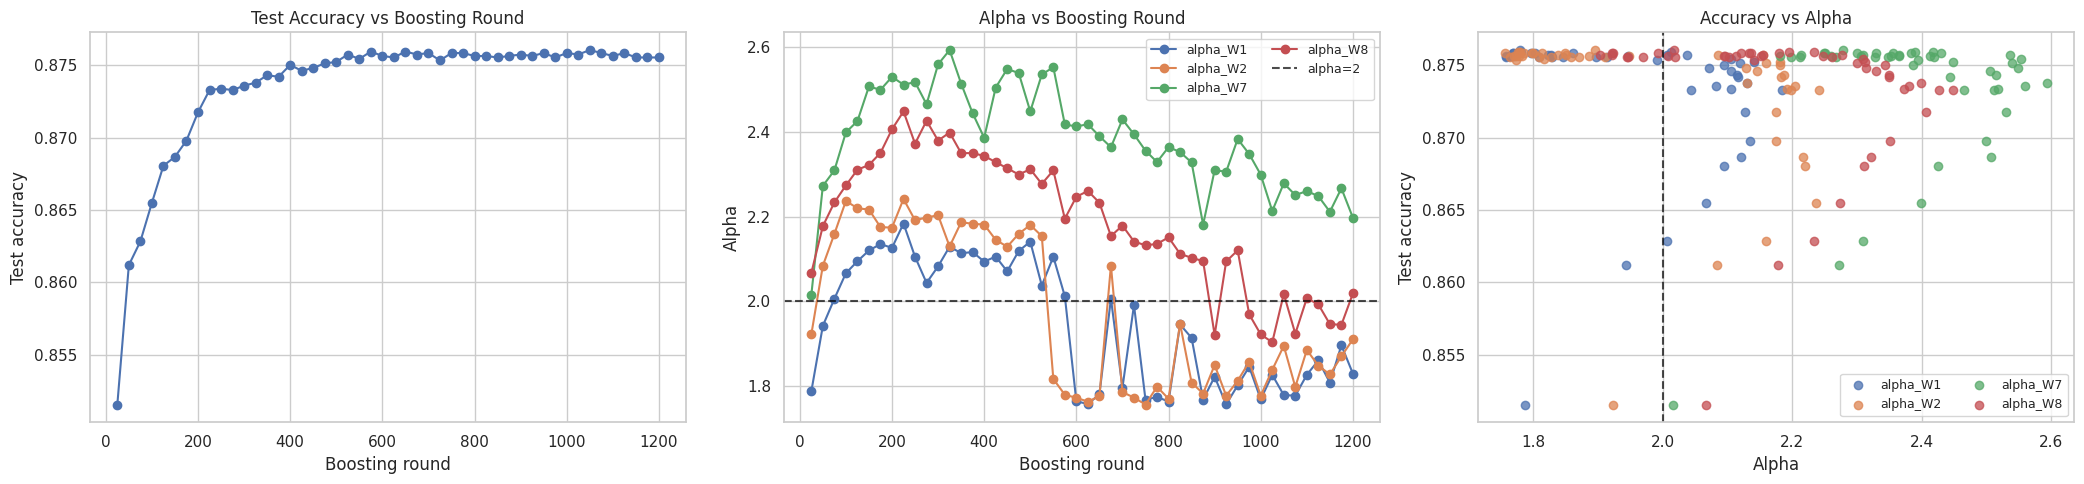

In [24]:
fig, axes = plt.subplots(1, 3, figsize=(21, 5))

alpha_cols = [c for c in results_df.columns if c.startswith('alpha_')]

# Plot 1: Accuracy vs boosting round
axes[0].plot(results_df['boosting_round'], results_df['test_accuracy'], marker='o')
axes[0].set_title('Test Accuracy vs Boosting Round')
axes[0].set_xlabel('Boosting round')
axes[0].set_ylabel('Test accuracy')

# Plot 2: Alpha vs boosting round (all requested W matrices)
for col in alpha_cols:
    axes[1].plot(results_df['boosting_round'], results_df[col], marker='o', label=col)
axes[1].axhline(2.0, linestyle='--', color='black', alpha=0.7, label='alpha=2')
axes[1].set_title('Alpha vs Boosting Round')
axes[1].set_xlabel('Boosting round')
axes[1].set_ylabel('Alpha')
axes[1].legend(ncol=2, fontsize=9)

# Plot 3: Accuracy vs alpha
for col in alpha_cols:
    axes[2].scatter(results_df[col], results_df['test_accuracy'], label=col, alpha=0.75)
axes[2].axvline(2.0, linestyle='--', color='black', alpha=0.7)
axes[2].set_title('Accuracy vs Alpha')
axes[2].set_xlabel('Alpha')
axes[2].set_ylabel('Test accuracy')
axes[2].legend(ncol=2, fontsize=9)

plt.tight_layout()
plt.show()


## 9) HTSR hypothesis check and final summary table

In [25]:
summary_cols = ['boosting_round', 'test_accuracy'] + [c for c in results_df.columns if c.startswith('alpha_')]

best_idx = results_df['test_accuracy'].idxmax()
best_row = results_df.loc[best_idx, summary_cols]
print('Best-accuracy row:')
display(best_row.to_frame().T)

near_best = results_df.sort_values('test_accuracy', ascending=False).head(10).copy()
near_best = near_best[summary_cols].sort_values('boosting_round')
print('Alpha values near peak accuracy (top-10 rounds):')
display(near_best)

print('\nStart -> end alpha trend:')
for col in [c for c in summary_cols if c.startswith('alpha_')]:
    print(f'{col}: {results_df[col].iloc[0]:.3f} -> {results_df[col].iloc[-1]:.3f}')

print('\nAccuracy/alpha correlations:')
for col in [c for c in summary_cols if c.startswith('alpha_')]:
    corr = results_df['test_accuracy'].corr(results_df[col])
    print(f'corr(test_accuracy, {col}) = {corr:.4f}')


Best-accuracy row:


,boosting_round,test_accuracy,alpha_W1,alpha_W2,alpha_W7,alpha_W8
41,1050.0,0.876036,1.778872,1.895066,2.278769,2.017572


Alpha values near peak accuracy (top-10 rounds):


,boosting_round,test_accuracy,alpha_W1,alpha_W2,alpha_W7,alpha_W8
22,575,0.875934,2.012229,1.779686,2.417712,2.195232
25,650,0.875934,1.780448,1.775969,2.389884,2.232980
27,700,0.875832,1.796433,1.786023,2.429537,2.179084
29,750,0.875832,1.767878,1.756657,2.355806,2.132450
30,775,0.875832,1.774652,1.798673,2.328937,2.135772
37,950,0.875832,1.801801,1.812554,2.383348,2.120569
39,1000,0.875832,1.768925,1.777419,2.299180,1.922166
41,1050,0.876036,1.778872,1.895066,2.278769,2.017572
42,1075,0.875832,1.777647,1.798154,2.250999,1.923736
44,1125,0.875832,1.860897,1.848425,2.248445,1.992996



Start -> end alpha trend:
alpha_W1: 1.788 -> 1.829
alpha_W2: 1.922 -> 1.911
alpha_W7: 2.015 -> 2.197
alpha_W8: 2.067 -> 2.019

Accuracy/alpha correlations:
corr(test_accuracy, alpha_W1) = -0.1672
corr(test_accuracy, alpha_W2) = -0.3624
corr(test_accuracy, alpha_W7) = 0.2414
corr(test_accuracy, alpha_W8) = -0.1623


### Interpretation guide
- Built for Adult Income with stronger regularization and long-run checkpointing.
- Tracks **W1, W2, W7, W8, W9, W10** at each checkpointed stage.
- HTSR-style behavior is suggested if test accuracy stabilizes while alpha values remain in a robust heavy-tailed range (often around/above 2).


In [1]:
df

NameError: name 'df' is not defined

In [7]:
import pandas as pd
results_df = pd.read_csv(results_path_csv)

<Axes: xlabel='test_accuracy', ylabel='alpha_W2'>

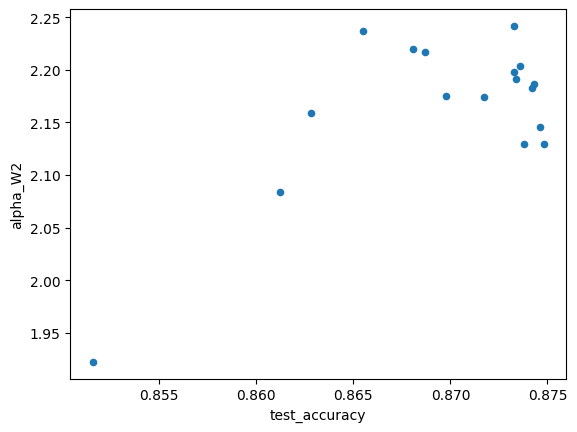

In [11]:
results_df[results_df.test_accuracy<0.875].plot.scatter(x='test_accuracy',y='alpha_W2')

<Axes: xlabel='boosting_round', ylabel='alpha_W7'>

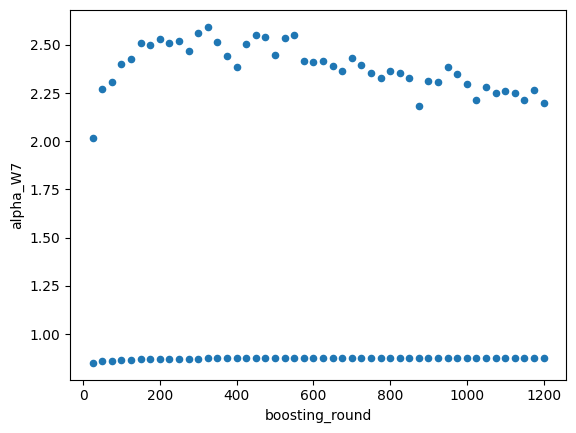

In [20]:
df = results_df
ax = df.plot.scatter(x='boosting_round', y='test_accuracy')
df.plot.scatter(x='boosting_round', y='alpha_W7', ax=ax)

In [26]:
!ls /content/drive/MyDrive/xgboost2ww_runs/adult_income_longrun_alpha_tracking2/models/

adult_income_longrun_latest.json      adult_income_longrun_round_450.json
adult_income_longrun_round_1000.json  adult_income_longrun_round_475.json
adult_income_longrun_round_100.json   adult_income_longrun_round_500.json
adult_income_longrun_round_1025.json  adult_income_longrun_round_50.json
adult_income_longrun_round_1050.json  adult_income_longrun_round_525.json
adult_income_longrun_round_1075.json  adult_income_longrun_round_550.json
adult_income_longrun_round_1100.json  adult_income_longrun_round_575.json
adult_income_longrun_round_1125.json  adult_income_longrun_round_600.json
adult_income_longrun_round_1150.json  adult_income_longrun_round_625.json
adult_income_longrun_round_1175.json  adult_income_longrun_round_650.json
adult_income_longrun_round_1200.json  adult_income_longrun_round_675.json
adult_income_longrun_round_125.json   adult_income_longrun_round_700.json
adult_income_longrun_round_150.json   adult_income_longrun_round_725.json
adult_income_longrun_round_175.json   a

In [33]:

import numpy as np
import pandas as pd
from scipy import sparse
from pathlib import Path

from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer

import xgboost as xgb
from xgboost2ww import convert

# ---------------------------
# Config
# ---------------------------
RANDOM_STATE = 42
ROUND_TO_LOAD = 550
W_LIST = ["W1", "W2", "W7"]

# If `models_dir` exists in notebook, this uses it.
# Otherwise set to your model folder manually.
if "models_dir" in globals():
    model_path_550 = models_dir / f"adult_income_longrun_round_{ROUND_TO_LOAD}.json"
else:
    model_path_550 = Path(f"adult_income_longrun_round_{ROUND_TO_LOAD}.json")  # <-- edit if needed

if not model_path_550.exists():
    raise FileNotFoundError(f"Model file not found: {model_path_550}")

# `params` is expected from your notebook; fallback provided
if "params" not in globals():
    params = {
        "max_depth": 4,
        "eta": 0.05,
        "subsample": 0.9,
        "colsample_bytree": 0.8,
        "min_child_weight": 5,
        "reg_lambda": 5.0,
        "reg_alpha": 0.5,
        "gamma": 1.0,
        "objective": "binary:logistic",
        "eval_metric": "logloss",
        "tree_method": "hist",
        "seed": RANDOM_STATE,
    }

# ---------------------------
# Rebuild training data
# ---------------------------
adult = fetch_openml(data_id=1590, as_frame=True, parser="auto")
df = adult.frame.copy()

y = (df["class"].astype(str).str.strip() == ">50K").astype(np.int32)
X_raw = df.drop(columns=["class"])

categorical_cols = X_raw.select_dtypes(include=["object", "category", "bool"]).columns
numeric_cols = X_raw.select_dtypes(exclude=["object", "category", "bool"]).columns

preprocessor = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_cols),
        ("num", "passthrough", numeric_cols),
    ]
)

X = preprocessor.fit_transform(X_raw).astype(np.float32)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

if sparse.issparse(X_train):
    scaler = StandardScaler(with_mean=False)
else:
    scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train).astype(np.float32)
y_train_np = np.asarray(y_train).astype(np.int32).reshape(-1)

# ---------------------------
# Load model @ round 550
# ---------------------------
bst_550 = xgb.Booster()
bst_550.load_model(str(model_path_550))
print(f"Loaded: {model_path_550}")

# ---------------------------
# Convert
# ---------------------------
if sparse.issparse(X_train_scaled):
    MAX_DENSE_ELEMENTS = int(2e8)  # safety
    dense_cost = int(X_train_scaled.shape[0]) * int(X_train_scaled.shape[1])
    if dense_cost > MAX_DENSE_ELEMENTS:
        raise MemoryError(f"Too large to densify: {X_train_scaled.shape}, elements={dense_cost:,}")
    X_for_convert = X_train_scaled.toarray().astype(np.float32)
else:
    X_for_convert = np.asarray(X_train_scaled, dtype=np.float32)

layers_550 = {}
for W_name in W_LIST:
    layers_550[W_name] = convert(
        model=bst_550,
        data=X_for_convert,
        labels=y_train_np,
        W=W_name,
        return_type="torch",
        nfolds=5,
        t_points=min(ROUND_TO_LOAD, 160),
        random_state=RANDOM_STATE,
        train_params=params,
        num_boost_round=ROUND_TO_LOAD,
        multiclass="error",
    )
    print(f"Converted {W_name}")

Loaded: /content/drive/MyDrive/xgboost2ww_runs/adult_income_longrun_alpha_tracking2/models/adult_income_longrun_round_550.json
Converted W1
Converted W2
Converted W7


In [36]:
!pip install weightwatcher

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 83.7/83.7 kB 4.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 192.0/192.0 kB 10.1 MB/s eta 0:00:00


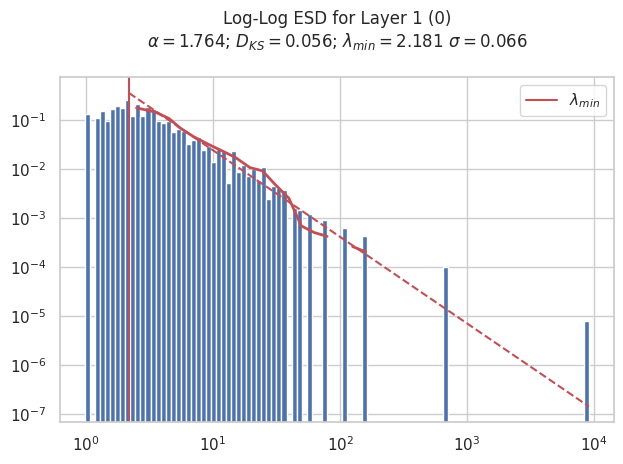

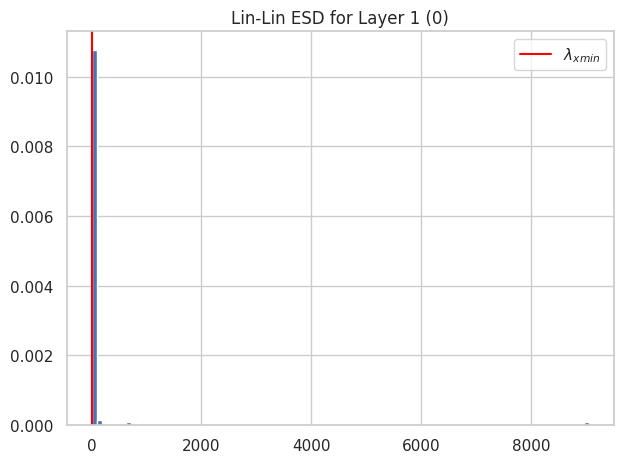

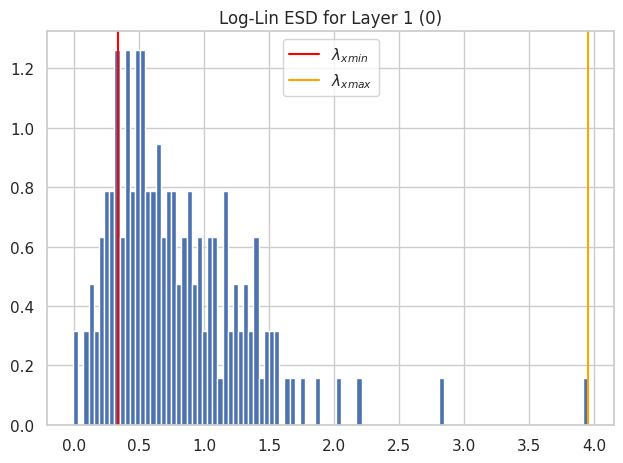

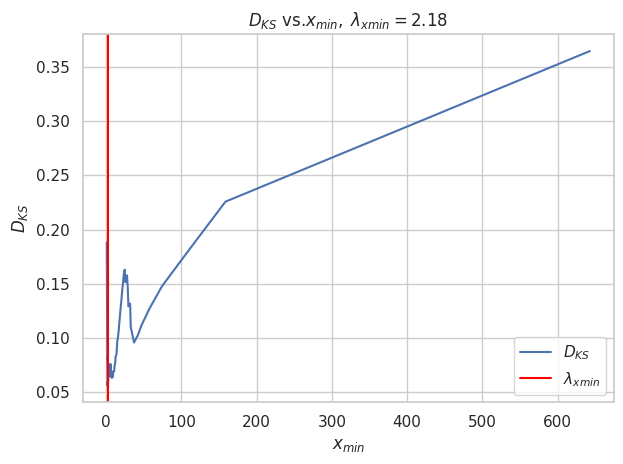

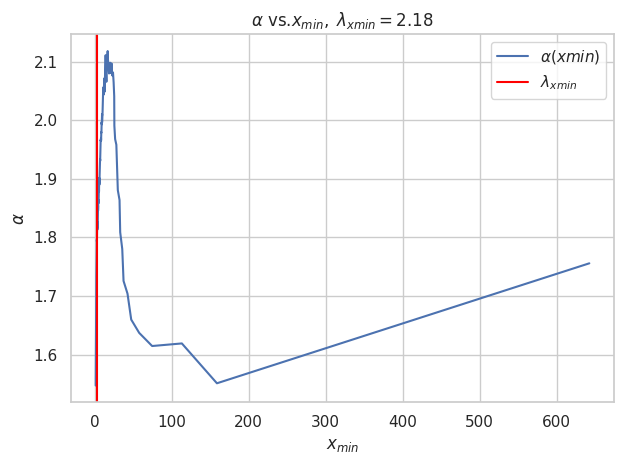

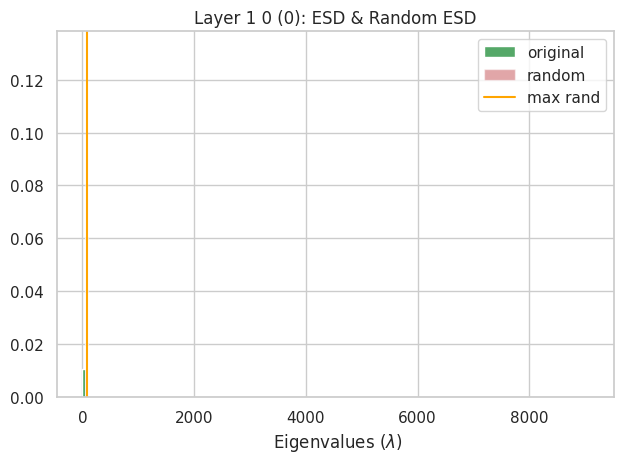

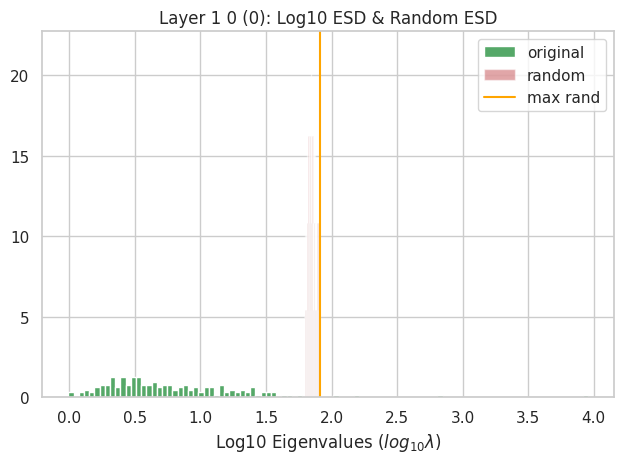

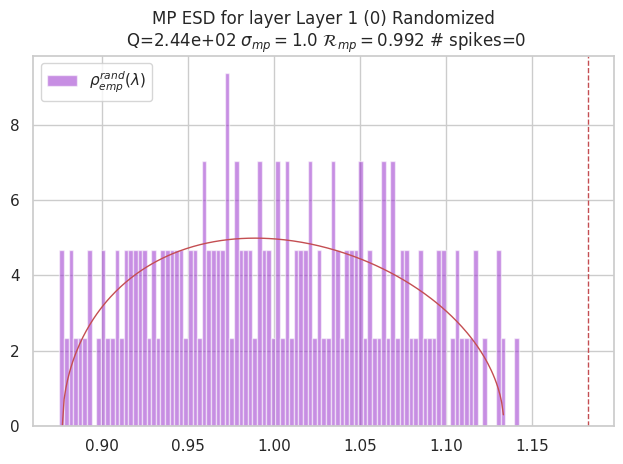

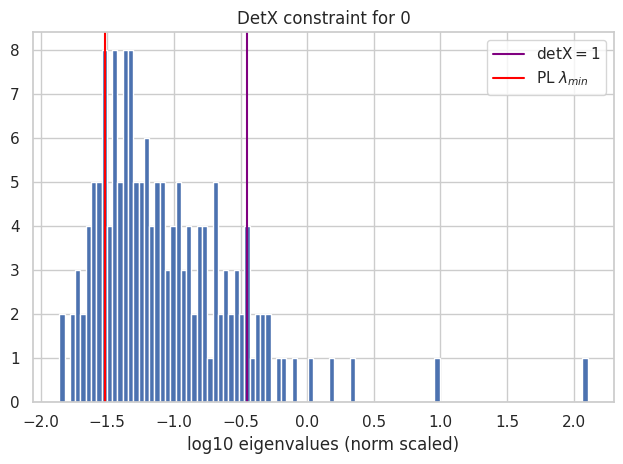

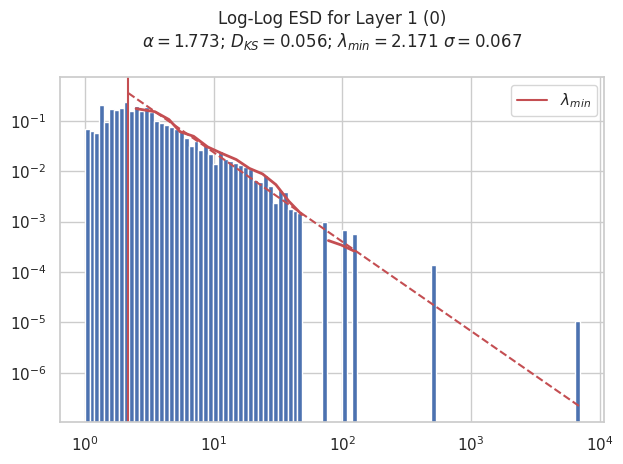

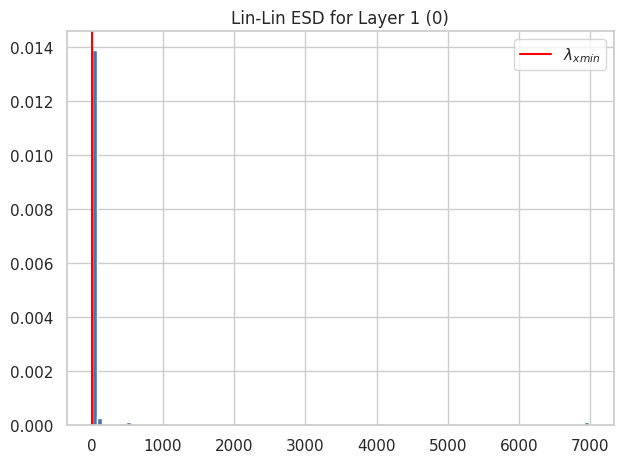

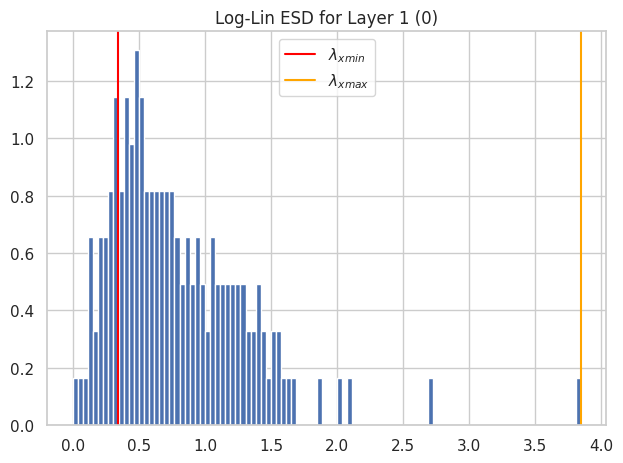

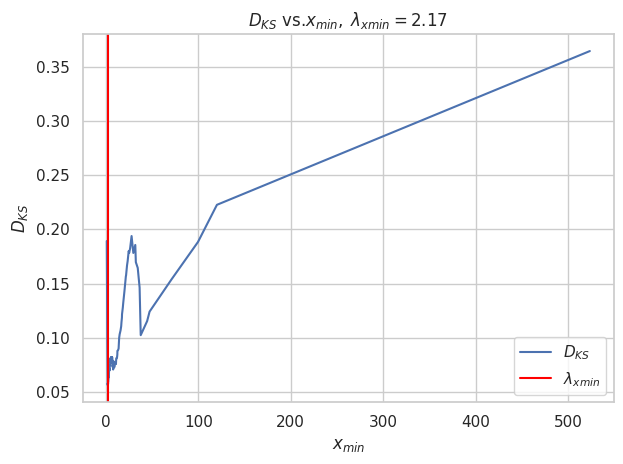

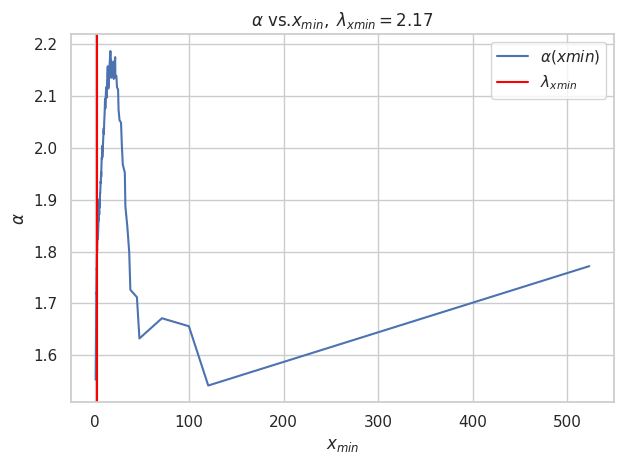

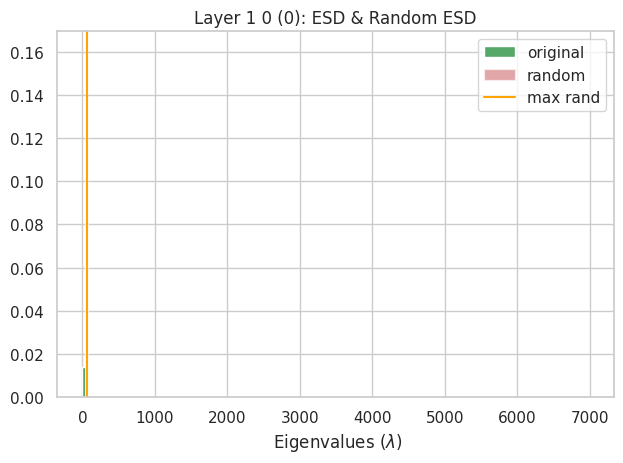

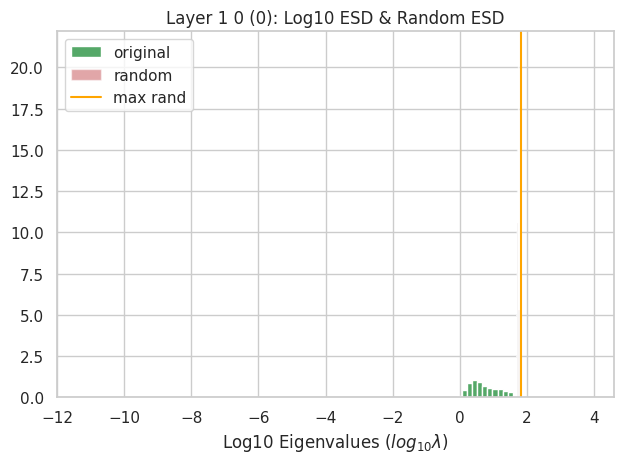

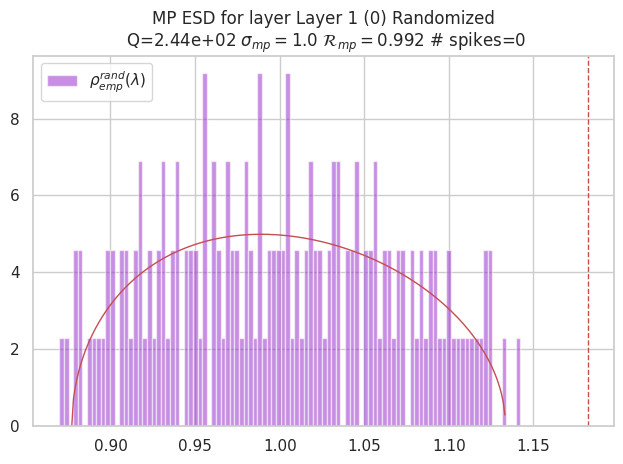

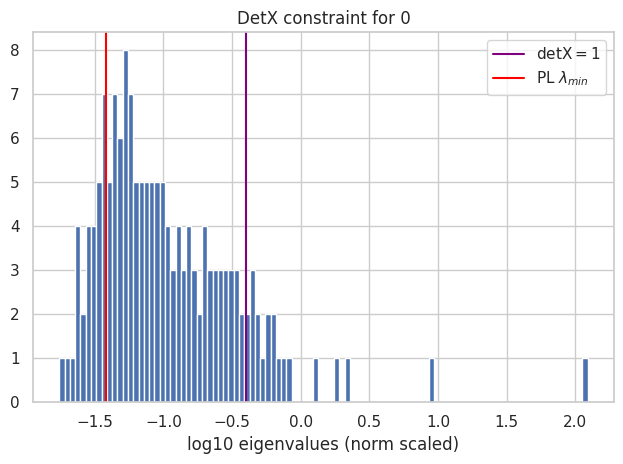

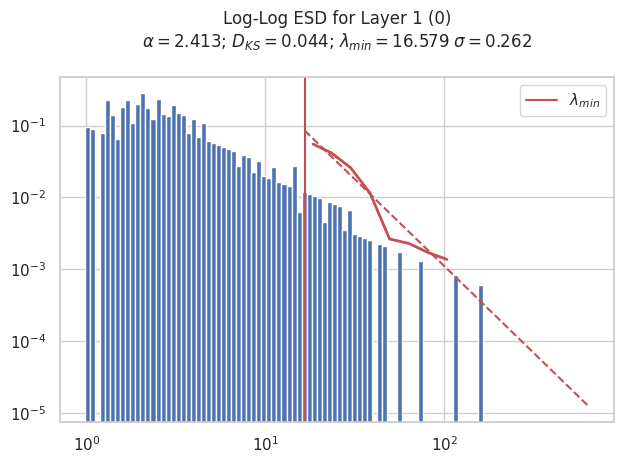

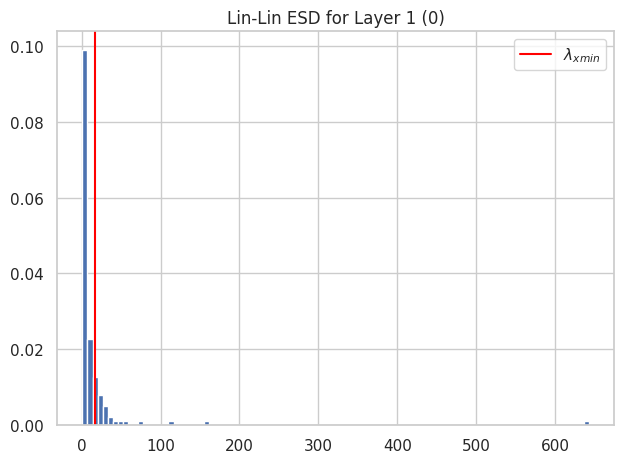

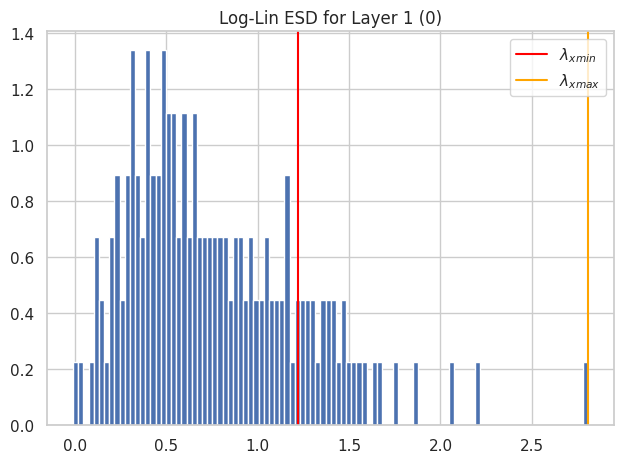

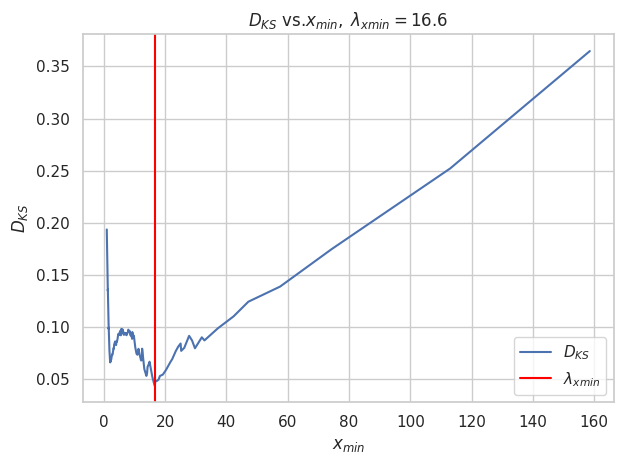

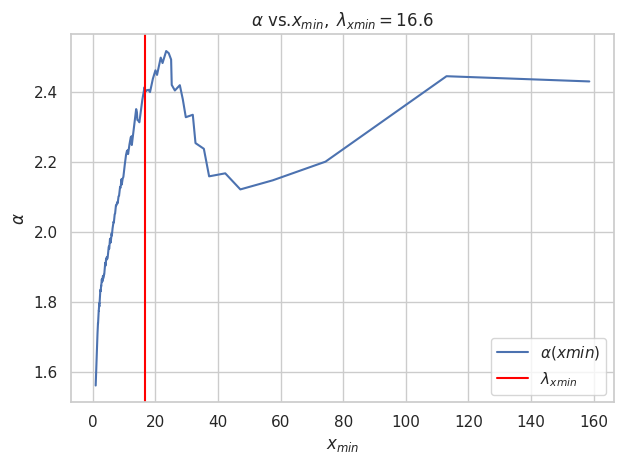

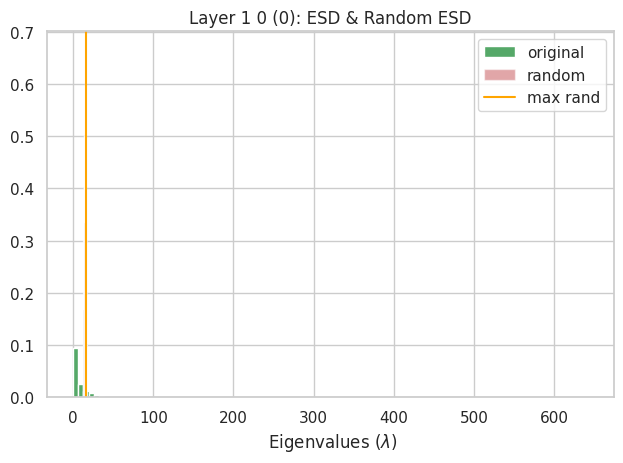

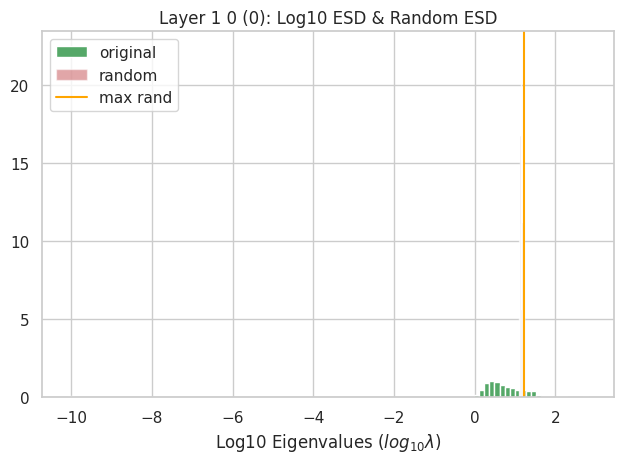

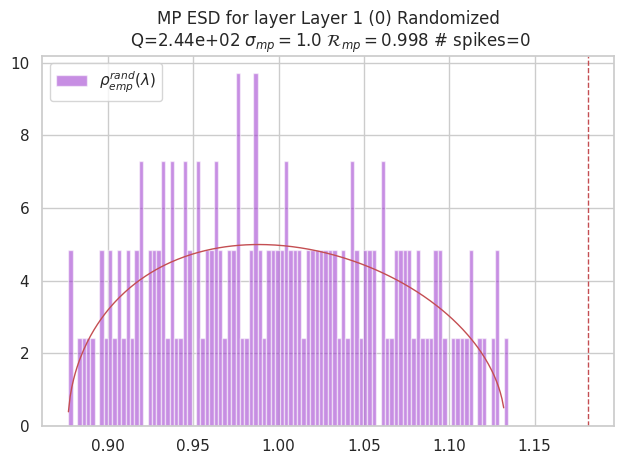

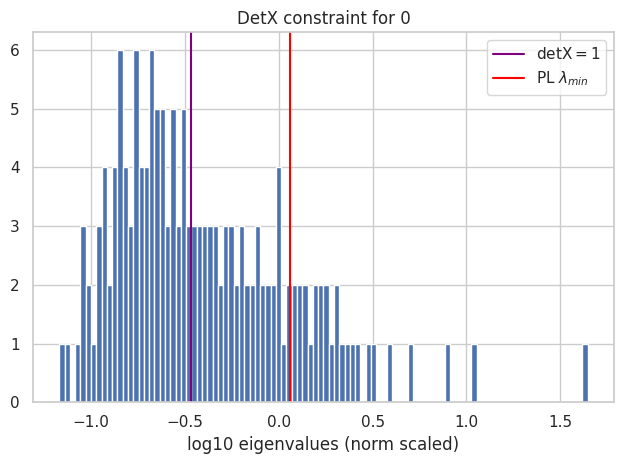

WeightWatcher summary:


,W,alpha,raw_alpha,log_norm,spectral_norm,stable_rank,D,num_evals
0,W1,1.763874,1.763874,4.056361,9059.851606,1.256725,0.056055,160.0
1,W2,1.772526,1.772526,3.959211,6983.589687,1.303564,0.056007,160.0
2,W7,2.412991,2.412991,3.366589,642.628728,3.619340,0.044138,160.0


/tmp/ipykernel_2478/2328118339.py:64: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=summary_df, x="W", y="alpha", ax=axes[0], palette="Blues_d")
/tmp/ipykernel_2478/2328118339.py:72: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=summary_df, x="W", y="spectral_norm", ax=axes[1], palette="Greens_d")
/tmp/ipykernel_2478/2328118339.py:82: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=summary_df, x="W", y="stable_rank", ax=axes[2], palette="Oranges_d")


<Figure size 640x480 with 0 Axes>

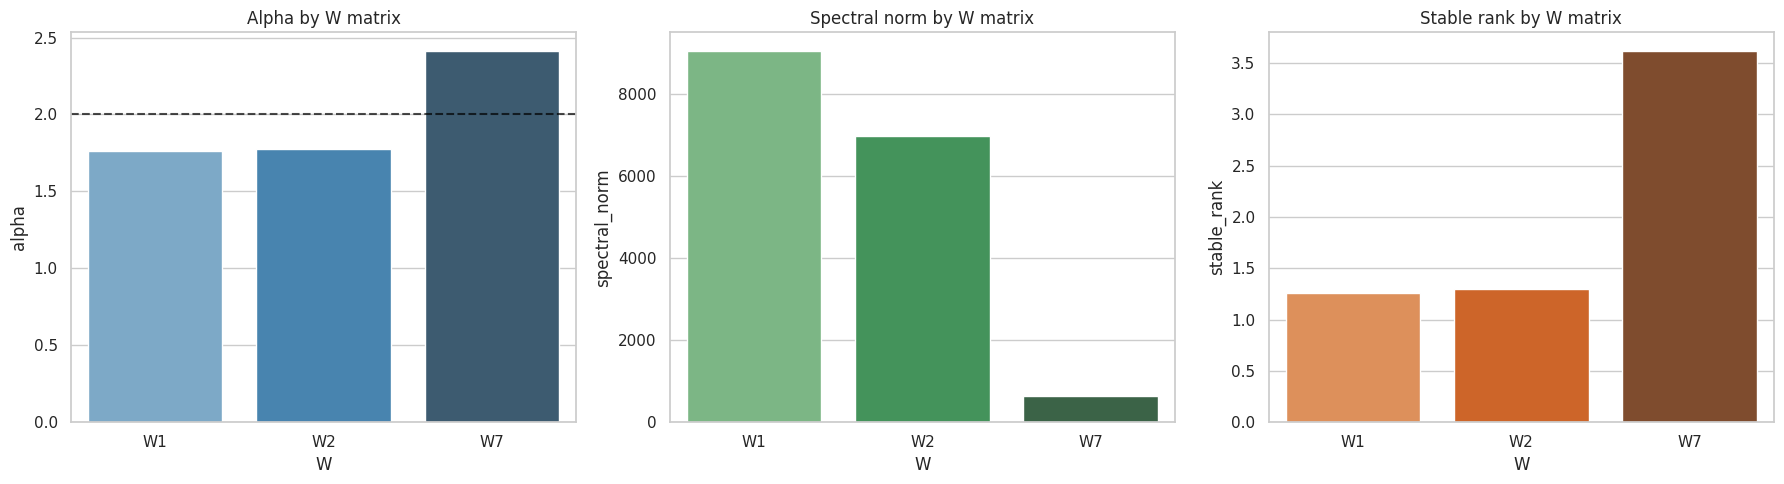

In [40]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import weightwatcher as ww

sns.set_theme(style="whitegrid")

# --------------------------------------------
# Expect these from previous cell:
#   bst_550, X_for_convert, y_train_np, params
# --------------------------------------------
required = ["bst_550", "X_for_convert", "y_train_np", "params"]
missing = [v for v in required if v not in globals()]
if missing:
    raise NameError(f"Missing required variables: {missing}. Run the load/convert prep cell first.")

ROUND_TO_LOAD = 600
W_LIST = ["W1", "W2", "W7"]

analysis_rows = []
analysis_tables = {}
layers_550 = {}

for W_name in W_LIST:
    # 1) Convert
    layer = convert(
        model=bst_550,
        data=X_for_convert,
        labels=y_train_np,
        W=W_name,
        return_type="torch",
        nfolds=5,
        t_points=min(ROUND_TO_LOAD, 160),
        random_state=42,
        train_params=params,
        num_boost_round=ROUND_TO_LOAD,
        multiclass="error",
    )
    layers_550[W_name] = layer

    # 2) Analyze with WeightWatcher
    watcher = ww.WeightWatcher(model=layer)
    df_ww = watcher.analyze(plot=True,randomize=True, detX=True, fix_fingers='clip_xmax')
    df_ww["W"] = W_name
    analysis_tables[W_name] = df_ww

    # collect scalar summary (if columns exist)
    row = {"W": W_name}
    for col in ["alpha", "raw_alpha", "log_norm", "spectral_norm", "stable_rank", "D", "num_evals"]:
        row[col] = float(df_ww[col].iloc[0]) if col in df_ww.columns else np.nan
    analysis_rows.append(row)

summary_df = pd.DataFrame(analysis_rows).sort_values("W").reset_index(drop=True)
print("WeightWatcher summary:")
display(summary_df)

# --------------------------------------------
# 3) Plot summary metrics
# --------------------------------------------
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Alpha bar plot
sns.barplot(data=summary_df, x="W", y="alpha", ax=axes[0], palette="Blues_d")
axes[0].axhline(2.0, ls="--", c="black", alpha=0.7)
axes[0].set_title("Alpha by W matrix")
axes[0].set_xlabel("W")
axes[0].set_ylabel("alpha")

# Spectral norm
if "spectral_norm" in summary_df.columns:
    sns.barplot(data=summary_df, x="W", y="spectral_norm", ax=axes[1], palette="Greens_d")
    axes[1].set_title("Spectral norm by W matrix")
    axes[1].set_xlabel("W")
    axes[1].set_ylabel("spectral_norm")
else:
    axes[1].text(0.5, 0.5, "spectral_norm not available", ha="center", va="center")
    axes[1].set_axis_off()

# Stable rank
if "stable_rank" in summary_df.columns:
    sns.barplot(data=summary_df, x="W", y="stable_rank", ax=axes[2], palette="Oranges_d")
    axes[2].set_title("Stable rank by W matrix")
    axes[2].set_xlabel("W")
    axes[2].set_ylabel("stable_rank")
else:
    axes[2].text(0.5, 0.5, "stable_rank not available", ha="center", va="center")
    axes[2].set_axis_off()

plt.tight_layout()
plt.show()